<a href="https://colab.research.google.com/github/k98j/Research-Projects/blob/main/Long_Horizon_Failure_of_Learned_World_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q gymnasium

In [2]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [3]:
env = gym.make("CartPole-v1")

obs, info = env.reset()

print(obs)

[-0.0428256  -0.04035755 -0.03860456 -0.00170255]


In [4]:
states = []
actions = []
next_states = []

obs, _ = env.reset()

for _ in range(10000):

    action = env.action_space.sample()

    next_obs, reward, terminated, truncated, info = env.step(action)

    states.append(obs)
    actions.append(action)
    next_states.append(next_obs)

    obs = next_obs

    if terminated or truncated:
        obs, _ = env.reset()

In [5]:
states = torch.tensor(
    np.array(states),
    dtype=torch.float32
)

actions = torch.tensor(
    np.array(actions),
    dtype=torch.float32
)

next_states = torch.tensor(
    np.array(next_states),
    dtype=torch.float32
)

In [6]:
class WorldModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(5,64),
            nn.ReLU(),

            nn.Linear(64,64),
            nn.ReLU(),

            nn.Linear(64,4)
        )

    def forward(self, state, action):

        x = torch.cat(
            [state, action.unsqueeze(1)],
            dim=1
        )

        return self.net(x)

In [7]:
world_model = WorldModel()

In [8]:
optimizer = torch.optim.Adam(
    world_model.parameters(),
    lr=1e-3
)

loss_fn = nn.MSELoss()

In [9]:
for epoch in range(30):

    pred = world_model(
        states,
        actions
    )

    loss = loss_fn(
        pred,
        next_states
    )

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 5 == 0:
        print(epoch, loss.item())

0 0.2530699074268341
5 0.2125047892332077
10 0.17492951452732086
15 0.13813765347003937
20 0.10345583409070969
25 0.07381224632263184


In [10]:
idx = 0

s = states[idx]
a = actions[idx]
real_next = next_states[idx]

with torch.no_grad():

    predicted_next = world_model(
        s.unsqueeze(0),
        a.unsqueeze(0)
    )[0]

print("Real:", real_next)
print("Predicted:", predicted_next)

Real: tensor([-0.0406, -0.1863, -0.0207,  0.2366])
Predicted: tensor([ 0.0478, -0.0676,  0.0368, -0.0499])


In [11]:
error = torch.norm(
    predicted_next - real_next
)

print(error.item())

0.3276159465312958


In [12]:
env = gym.make("CartPole-v1")

obs, _ = env.reset()

trajectory_states = [obs]
trajectory_actions = []

for _ in range(20):

    action = env.action_space.sample()

    next_obs, reward, terminated, truncated, _ = env.step(action)

    trajectory_actions.append(action)
    trajectory_states.append(next_obs)

    obs = next_obs

    if terminated or truncated:
        break

In [13]:
predicted_states = [
    trajectory_states[0]
]

current_state = torch.tensor(
    trajectory_states[0],
    dtype=torch.float32
)

In [14]:
for action in trajectory_actions:

    action_tensor = torch.tensor(
        float(action),
        dtype=torch.float32
    )

    with torch.no_grad():

        current_state = world_model(
            current_state.unsqueeze(0),
            action_tensor.unsqueeze(0)
        )[0]

    predicted_states.append(
        current_state.numpy()
    )

In [15]:
errors = []

for real, predicted in zip(
    trajectory_states,
    predicted_states
):

    error = np.linalg.norm(
        np.array(real) -
        np.array(predicted)
    )

    errors.append(error)

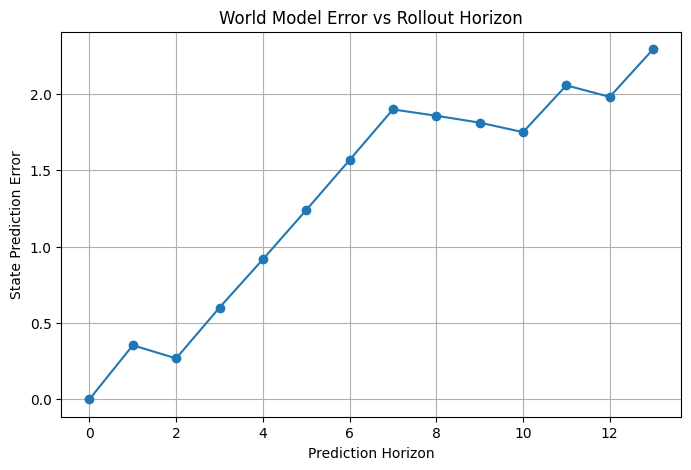

In [16]:
plt.figure(figsize=(8,5))

plt.plot(
    range(len(errors)),
    errors,
    marker="o"
)

plt.xlabel("Prediction Horizon")
plt.ylabel("State Prediction Error")

plt.title(
    "World Model Error vs Rollout Horizon"
)

plt.grid()

plt.show()

In [17]:
mean_error[horizon]

NameError: name 'mean_error' is not defined

In [18]:
all_errors = []

for episode in range(20):

    env = gym.make("CartPole-v1")
    obs, _ = env.reset()

    trajectory_states = [obs]
    trajectory_actions = []

    for _ in range(20):

        action = env.action_space.sample()

        next_obs, reward, terminated, truncated, _ = env.step(action)

        trajectory_actions.append(action)
        trajectory_states.append(next_obs)

        obs = next_obs

        if terminated or truncated:
            break

    env.close()

    # Model rollout
    predicted_states = [trajectory_states[0]]

    current_state = torch.tensor(
        trajectory_states[0],
        dtype=torch.float32
    )

    for action in trajectory_actions:

        action_tensor = torch.tensor(
            float(action),
            dtype=torch.float32
        )

        with torch.no_grad():
            current_state = world_model(
                current_state.unsqueeze(0),
                action_tensor.unsqueeze(0)
            )[0]

        predicted_states.append(current_state.numpy())

    # Error at each horizon
    errors_episode = []

    for real, predicted in zip(
        trajectory_states,
        predicted_states
    ):

        error = np.linalg.norm(
            np.array(real) - np.array(predicted)
        )

        errors_episode.append(error)

    all_errors.append(errors_episode)


print("Completed", len(all_errors), "episodes")

Completed 20 episodes


In [19]:
min_length = min(len(x) for x in all_errors)

errors_array = np.array([
    x[:min_length]
    for x in all_errors
])

mean_error = errors_array.mean(axis=0)
std_error = errors_array.std(axis=0)

print("Mean error:", mean_error)

Mean error: [0.         0.2021466  0.32193264 0.47554785 0.5205075  0.6334146
 0.6814076  0.7573355  0.8201534  0.8217864  0.87727785]


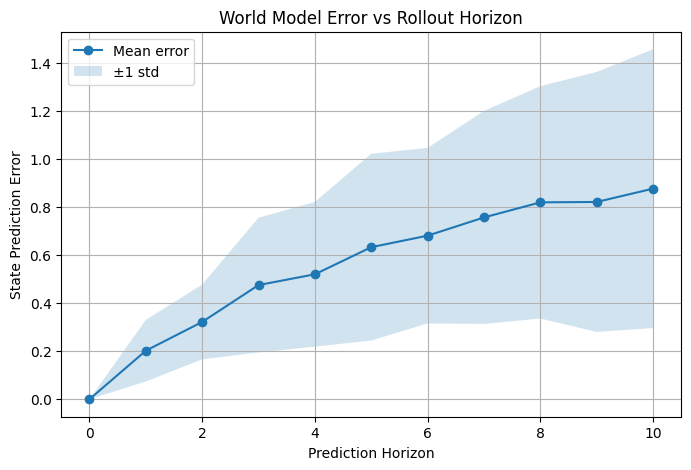

In [20]:
plt.figure(figsize=(8,5))

horizons = np.arange(min_length)

plt.plot(
    horizons,
    mean_error,
    marker="o",
    label="Mean error"
)

plt.fill_between(
    horizons,
    mean_error - std_error,
    mean_error + std_error,
    alpha=0.2,
    label="±1 std"
)

plt.xlabel("Prediction Horizon")
plt.ylabel("State Prediction Error")
plt.title("World Model Error vs Rollout Horizon")

plt.legend()
plt.grid()

plt.show()

In [21]:
plt.savefig(
    "rollout_error.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [22]:
def policy(obs):
    if obs[2] < 0:
        return 0
    else:
        return 1

In [23]:
env = gym.make("CartPole-v1")

obs, _ = env.reset()

trajectory_states = [obs]
trajectory_actions = []

for _ in range(20):

    action = policy(obs)

    next_obs, reward, terminated, truncated, _ = env.step(action)

    trajectory_actions.append(action)
    trajectory_states.append(next_obs)

    obs = next_obs

    if terminated or truncated:
        break

env.close()

In [24]:
predicted_states = [trajectory_states[0]]

current_state = torch.tensor(
    trajectory_states[0],
    dtype=torch.float32
)

for action in trajectory_actions:

    action_tensor = torch.tensor(
        float(action),
        dtype=torch.float32
    )

    with torch.no_grad():
        current_state = world_model(
            current_state.unsqueeze(0),
            action_tensor.unsqueeze(0)
        )[0]

    predicted_states.append(current_state.numpy())

In [25]:
shift_errors = []

for real, predicted in zip(
    trajectory_states,
    predicted_states
):

    error = np.linalg.norm(
        np.array(real) - np.array(predicted)
    )

    shift_errors.append(error)

print(shift_errors)

[np.float32(0.0), np.float32(0.089636005), np.float32(0.17100078), np.float32(0.26710168), np.float32(0.39227423), np.float32(0.17279197), np.float32(0.17523822), np.float32(0.40105003), np.float32(0.65317476), np.float32(0.9121922), np.float32(1.177615), np.float32(1.4490418), np.float32(1.7313834), np.float32(2.0254104), np.float32(2.331381), np.float32(2.257473), np.float32(2.166832), np.float32(2.0527754), np.float32(1.9206262), np.float32(1.7745036), np.float32(1.6137295)]


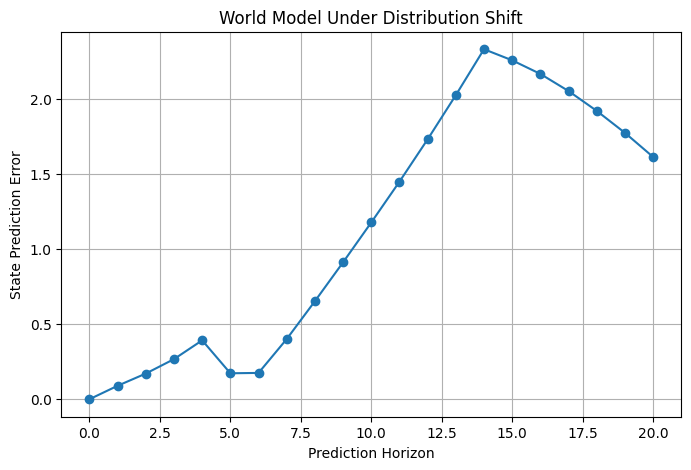

In [26]:
plt.figure(figsize=(8,5))

plt.plot(
    range(len(shift_errors)),
    shift_errors,
    marker="o"
)

plt.xlabel("Prediction Horizon")
plt.ylabel("State Prediction Error")
plt.title("World Model Under Distribution Shift")

plt.grid()

plt.show()

In [27]:
plt.savefig(
    "distribution_shift.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>